In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

# Settings — exactly as you have them
EMA_FAST  = 8
EMA_MID   = 21
EMA_SLOW  = 89
RSI_LEN   = 14
ATR_LEN   = 14
ADX_LEN   = 14
ADX_MIN   = 15
SL_MULT   = 1.0
TP1_MULT  = 2.0
TP2_MULT  = 4.0
UTC_OFFSET = 3   # your UTC+3

print("LIP-SIM Backtest Engine")
print("=" * 40)
print(f"EMA: {EMA_FAST}/{EMA_MID}/{EMA_SLOW}")
print(f"RSI: {RSI_LEN} | ATR: {ATR_LEN} | ADX: {ADX_MIN}+")
print(f"SL: {SL_MULT}x ATR | TP1: {TP1_MULT}x | TP2: {TP2_MULT}x")
print(f"UTC Offset: +{UTC_OFFSET}")

LIP-SIM Backtest Engine
EMA: 8/21/89
RSI: 14 | ATR: 14 | ADX: 15+
SL: 1.0x ATR | TP1: 2.0x | TP2: 4.0x
UTC Offset: +3


In [4]:
from datetime import datetime, timedelta

# Calculate date 700 days ago to stay within Yahoo's limit
end_date   = datetime.today().strftime('%Y-%m-%d')
start_date = (datetime.today() - timedelta(days=700)).strftime('%Y-%m-%d')

print(f"Fetching H1 GLD from {start_date} to {end_date}")

raw = yf.download("GLD", start=start_date,
                   end=end_date, interval="1h",
                   auto_adjust=True)
raw.columns = raw.columns.get_level_values(0)
raw = raw.dropna()

df = raw.copy()
df.columns = [c.lower() for c in df.columns]

print(f"Loaded {len(df)} hourly bars")
print(f"Date range: {df.index[0]} to {df.index[-1]}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nNote: GLD price ≈ XAU/USD / 10")
print(f"GLD current: ${df['close'].iloc[-1]:.2f}")
print(f"Implied XAU/USD: ${df['close'].iloc[-1]*10:.2f}")

Fetching H1 GLD from 2024-08-08 to 2026-07-09


[*********************100%***********************]  1 of 1 completed

Loaded 3333 hourly bars
Date range: 2024-08-08 13:30:00+00:00 to 2026-07-08 19:30:00+00:00
Columns: ['close', 'high', 'low', 'open', 'volume']

Note: GLD price ≈ XAU/USD / 10
GLD current: $374.47
Implied XAU/USD: $3744.70


In [5]:
# ── INDICATORS ───────────────────────────────────────────

def ema(series, length):
    return series.ewm(span=length, adjust=False).mean()

def rsi(series, length=14):
    delta = series.diff()
    gain  = delta.clip(lower=0).rolling(length).mean()
    loss  = (-delta.clip(upper=0)).rolling(length).mean()
    rs    = gain / loss
    return 100 - (100 / (1 + rs))

def atr(high, low, close, length=14):
    tr = pd.concat([
        high - low,
        (high - close.shift(1)).abs(),
        (low  - close.shift(1)).abs()
    ], axis=1).max(axis=1)
    return tr.rolling(length).mean()

def adx(high, low, close, length=14):
    tr   = pd.concat([
        high - low,
        (high - close.shift(1)).abs(),
        (low  - close.shift(1)).abs()
    ], axis=1).max(axis=1)
    atr_ = tr.rolling(length).mean()

    up   = high.diff()
    down = -low.diff()
    dm_p = pd.Series(np.where((up > down) & (up > 0), up, 0), index=high.index)
    dm_m = pd.Series(np.where((down > up) & (down > 0), down, 0), index=high.index)

    di_p = 100 * dm_p.rolling(length).mean() / atr_
    di_m = 100 * dm_m.rolling(length).mean() / atr_
    dx   = 100 * (di_p - di_m).abs() / (di_p + di_m)
    return dx.rolling(length).mean()

def macd(series, fast=8, slow=17, signal=9):
    ml = ema(series, fast) - ema(series, slow)
    ms = ml.ewm(span=signal, adjust=False).mean()
    return ml, ms

# Calculate all indicators
df['ema_fast'] = ema(df['close'], EMA_FAST)
df['ema_mid']  = ema(df['close'], EMA_MID)
df['ema_slow'] = ema(df['close'], EMA_SLOW)
df['rsi']      = rsi(df['close'], RSI_LEN)
df['atr']      = atr(df['high'], df['low'], df['close'], ATR_LEN)
df['adx']      = adx(df['high'], df['low'], df['close'], ADX_LEN)
df['macd_l'], df['macd_s'] = macd(df['close'])

# Session detection (UTC + offset)
df['hour'] = (df.index.hour + UTC_OFFSET) % 24
df['in_london']  = (df['hour'] >= 8)  & (df['hour'] < 17)
df['in_ny']      = (df['hour'] >= 13) & (df['hour'] < 22)
df['in_tokyo']   = (df['hour'] >= 0)  & (df['hour'] < 9)
df['in_overlap'] = (df['hour'] >= 13) & (df['hour'] < 17)
df['in_session'] = df['in_london'] | df['in_ny']

df = df.dropna()
print(f"Indicators calculated: {len(df)} bars remaining")
print(f"\nSample indicators:")
print(df[['close','ema_fast','ema_mid','ema_slow',
          'rsi','adx','atr']].tail(3).round(2))

Indicators calculated: 3307 bars remaining

Sample indicators:
                            close  ema_fast  ema_mid  ema_slow    rsi    adx  \
Datetime                                                                       
2026-07-08 17:30:00+00:00  373.46    374.32   376.16    378.52  27.92  46.92   
2026-07-08 18:30:00+00:00  375.15    374.51   376.07    378.44  33.34  46.00   
2026-07-08 19:30:00+00:00  374.47    374.50   375.92    378.36  32.07  43.51   

                            atr  
Datetime                         
2026-07-08 17:30:00+00:00  2.10  
2026-07-08 18:30:00+00:00  2.21  
2026-07-08 19:30:00+00:00  2.25  


In [7]:
# ── SIGNAL CONDITIONS (exact translation from Pine Script) ──

# Trend conditions
df['bull_trend'] = (df['ema_fast'] > df['ema_mid']) & \
                   (df['ema_fast'] > df['ema_slow'])
df['bear_trend'] = (df['ema_fast'] < df['ema_mid']) & \
                   (df['ema_fast'] < df['ema_slow'])

# Price vs EMAs
df['price_bull'] = (df['close'] > df['ema_fast']) & \
                   (df['close'] > df['ema_mid'])
df['price_bear'] = (df['close'] < df['ema_fast']) & \
                   (df['close'] < df['ema_mid'])

# RSI conditions
df['rsi_bull'] = (df['rsi'] > 50) & (df['rsi'] < 80)
df['rsi_bear'] = (df['rsi'] < 50) & (df['rsi'] > 20)

# MACD conditions
df['macd_bull'] = df['macd_l'] > df['macd_s']
df['macd_bear'] = df['macd_l'] < df['macd_s']

# ADX trend strength
df['has_trend'] = df['adx'] >= ADX_MIN

# Entry triggers — crossovers
df['cross_bull']  = (df['ema_fast'] > df['ema_mid']) & \
                    (df['ema_fast'].shift(1) <= df['ema_mid'].shift(1))
df['cross_bear']  = (df['ema_fast'] < df['ema_mid']) & \
                    (df['ema_fast'].shift(1) >= df['ema_mid'].shift(1))
df['macd_x_bull'] = (df['macd_l'] > df['macd_s']) & \
                    (df['macd_l'].shift(1) <= df['macd_s'].shift(1))
df['macd_x_bear'] = (df['macd_l'] < df['macd_s']) & \
                    (df['macd_l'].shift(1) >= df['macd_s'].shift(1))
df['rsi_x_bull']  = (df['rsi'] > 50) & (df['rsi'].shift(1) <= 50)
df['rsi_x_bear']  = (df['rsi'] < 50) & (df['rsi'].shift(1) >= 50)

# Combined triggers
df['trigger_bull'] = df['cross_bull']  | df['macd_x_bull'] | df['rsi_x_bull']
df['trigger_bear'] = df['cross_bear']  | df['macd_x_bear'] | df['rsi_x_bear']

# ── FINAL SIGNALS ──────────────────────────────────────────
df['buy']  = (df['trigger_bull'] & df['bull_trend'] &
              df['price_bull']   & df['rsi_bull']   &
              df['macd_bull']    & df['has_trend'])

df['sell'] = (df['trigger_bear'] & df['bear_trend'] &
              df['price_bear']   & df['rsi_bear']   &
              df['macd_bear']    & df['has_trend'])

# Confluence score
df['bull_score'] = (
    df['bull_trend'].astype(int) +
    df['price_bull'].astype(int) +
    df['rsi_bull'].astype(int)   +
    df['macd_bull'].astype(int)  +
    df['has_trend'].astype(int)  +
    (df['close'] > df['ema_slow']).astype(int) +
    df['in_overlap'].astype(int)
)

df['bear_score'] = (
    df['bear_trend'].astype(int) +
    df['price_bear'].astype(int) +
    df['rsi_bear'].astype(int)   +
    df['macd_bear'].astype(int)  +
    df['has_trend'].astype(int)  +
    (df['close'] < df['ema_slow']).astype(int) +
    df['in_overlap'].astype(int)
)

# Signal counts
n_buy  = df['buy'].sum()
n_sell = df['sell'].sum()

print(f"Signal generation complete")
print(f"{'='*45}")
print(f"  BUY signals  : {n_buy}")
print(f"  SELL signals : {n_sell}")
print(f"  Total signals: {n_buy + n_sell}")
print(f"  Signal rate  : {(n_buy+n_sell)/len(df)*100:.1f}% of bars")
print(f"{'='*45}")

# Grade A signals only
grade_a_buy  = (df['buy']  & (df['bull_score'] >= 6)).sum()
grade_a_sell = (df['sell'] & (df['bear_score'] >= 6)).sum()
print(f"\n  Grade A BUY  : {grade_a_buy}")
print(f"  Grade A SELL : {grade_a_sell}")

Signal generation complete
  BUY signals  : 79
  SELL signals : 32
  Total signals: 111
  Signal rate  : 3.4% of bars

  Grade A BUY  : 79
  Grade A SELL : 32


In [8]:
# ── BACKTEST ENGINE ──────────────────────────────────────
# Simulate each signal with ATR-based SL and TP
# Exit at TP1 (2x ATR) or SL (1x ATR)
# Use bar-by-bar simulation for realism

results = []

for i in range(len(df)):
    row = df.iloc[i]

    if not (row['buy'] or row['sell']):
        continue

    direction = 'LONG' if row['buy'] else 'SHORT'
    entry     = row['close']
    atr_val   = row['atr']
    bar_time  = df.index[i]

    # Calculate levels
    if direction == 'LONG':
        sl  = entry - atr_val * SL_MULT
        tp1 = entry + atr_val * TP1_MULT
        tp2 = entry + atr_val * TP2_MULT
    else:
        sl  = entry + atr_val * SL_MULT
        tp1 = entry - atr_val * TP1_MULT
        tp2 = entry - atr_val * TP2_MULT

    # Simulate forward bars to find exit
    outcome    = None
    exit_price = None
    exit_bar   = None
    max_bars   = 48  # max hold 48 hours

    for j in range(i+1, min(i+1+max_bars, len(df))):
        future = df.iloc[j]

        if direction == 'LONG':
            if future['low'] <= sl:
                outcome    = 'LOSS'
                exit_price = sl
                exit_bar   = j
                break
            elif future['high'] >= tp1:
                outcome    = 'WIN'
                exit_price = tp1
                exit_bar   = j
                break
        else:
            if future['high'] >= sl:
                outcome    = 'LOSS'
                exit_price = sl
                exit_bar   = j
                break
            elif future['low'] <= tp1:
                outcome    = 'WIN'
                exit_price = tp1
                exit_bar   = j
                break

    if outcome is None:
        outcome    = 'BE'
        exit_price = df.iloc[min(i+max_bars, len(df)-1)]['close']
        exit_bar   = min(i+max_bars, len(df)-1)

    # Calculate R
    risk = abs(entry - sl)
    if outcome == 'WIN':
        actual_r = abs(exit_price - entry) / risk
    elif outcome == 'LOSS':
        actual_r = -abs(exit_price - entry) / risk
    else:
        actual_r = (exit_price - entry) / risk if direction=='LONG' \
                   else (entry - exit_price) / risk

    # Session at entry
    h = (bar_time.hour + UTC_OFFSET) % 24
    if 13 <= h < 17:   session = 'Overlap'
    elif 8 <= h < 17:  session = 'London'
    elif 13 <= h < 22: session = 'NY'
    elif 0 <= h < 9:   session = 'Tokyo'
    else:              session = 'Off'

    results.append({
        'date'      : bar_time,
        'direction' : direction,
        'entry'     : entry,
        'sl'        : sl,
        'tp1'       : tp1,
        'exit_price': exit_price,
        'outcome'   : outcome,
        'actual_r'  : actual_r,
        'session'   : session,
        'bull_score': row['bull_score'],
        'bear_score': row['bear_score'],
        'adx'       : row['adx'],
        'bars_held' : (exit_bar - i) if exit_bar else max_bars
    })

results_df = pd.DataFrame(results)

# Summary
wins   = (results_df['outcome']=='WIN').sum()
losses = (results_df['outcome']=='LOSS').sum()
be     = (results_df['outcome']=='BE').sum()
wr     = wins / len(results_df)
avg_w  = results_df[results_df['outcome']=='WIN']['actual_r'].mean()
avg_l  = results_df[results_df['outcome']=='LOSS']['actual_r'].mean()
exp    = (wr * avg_w) + ((1-wr) * abs(avg_l))
total_r = results_df['actual_r'].sum()

print(f"\n{'='*55}")
print(f"  LIP-SIM BACKTEST RESULTS — GLD H1 (2yr)")
print(f"{'='*55}")
print(f"  Total signals  : {len(results_df)}")
print(f"  Wins/Losses/BE : {wins}/{losses}/{be}")
print(f"  Win rate       : {wr:.1%}")
print(f"  Avg win        : +{avg_w:.2f}R")
print(f"  Avg loss       : -{abs(avg_l):.2f}R")
print(f"  Expectancy     : {exp:.3f}R per trade")
print(f"  Total R        : {total_r:.2f}R")
print(f"{'='*55}")

# By direction
print(f"\n  BY DIRECTION:")
for d in ['LONG', 'SHORT']:
    sub = results_df[results_df['direction']==d]
    dwr = (sub['outcome']=='WIN').mean()
    der = sub['actual_r'].mean()
    print(f"  {d:<8} n:{len(sub):>3}  WR:{dwr:.0%}  "
          f"Avg R:{der:>+.2f}  Total:{sub['actual_r'].sum():.1f}R")

# By session
print(f"\n  BY SESSION:")
for s in results_df['session'].unique():
    sub = results_df[results_df['session']==s]
    swr = (sub['outcome']=='WIN').mean()
    ser = sub['actual_r'].mean()
    print(f"  {s:<10} n:{len(sub):>3}  WR:{swr:.0%}  "
          f"Avg R:{ser:>+.2f}  Total:{sub['actual_r'].sum():.1f}R")


  LIP-SIM BACKTEST RESULTS — GLD H1 (2yr)
  Total signals  : 111
  Wins/Losses/BE : 45/66/0
  Win rate       : 40.5%
  Avg win        : +2.00R
  Avg loss       : -1.00R
  Expectancy     : 1.405R per trade
  Total R        : 24.00R

  BY DIRECTION:
  LONG     n: 79  WR:44%  Avg R:+0.33  Total:26.0R
  SHORT    n: 32  WR:31%  Avg R:-0.06  Total:-2.0R

  BY SESSION:
  Overlap    n: 22  WR:45%  Avg R:+0.36  Total:8.0R
  NY         n: 81  WR:40%  Avg R:+0.19  Total:15.0R
  Off        n:  8  WR:38%  Avg R:+0.12  Total:1.0R


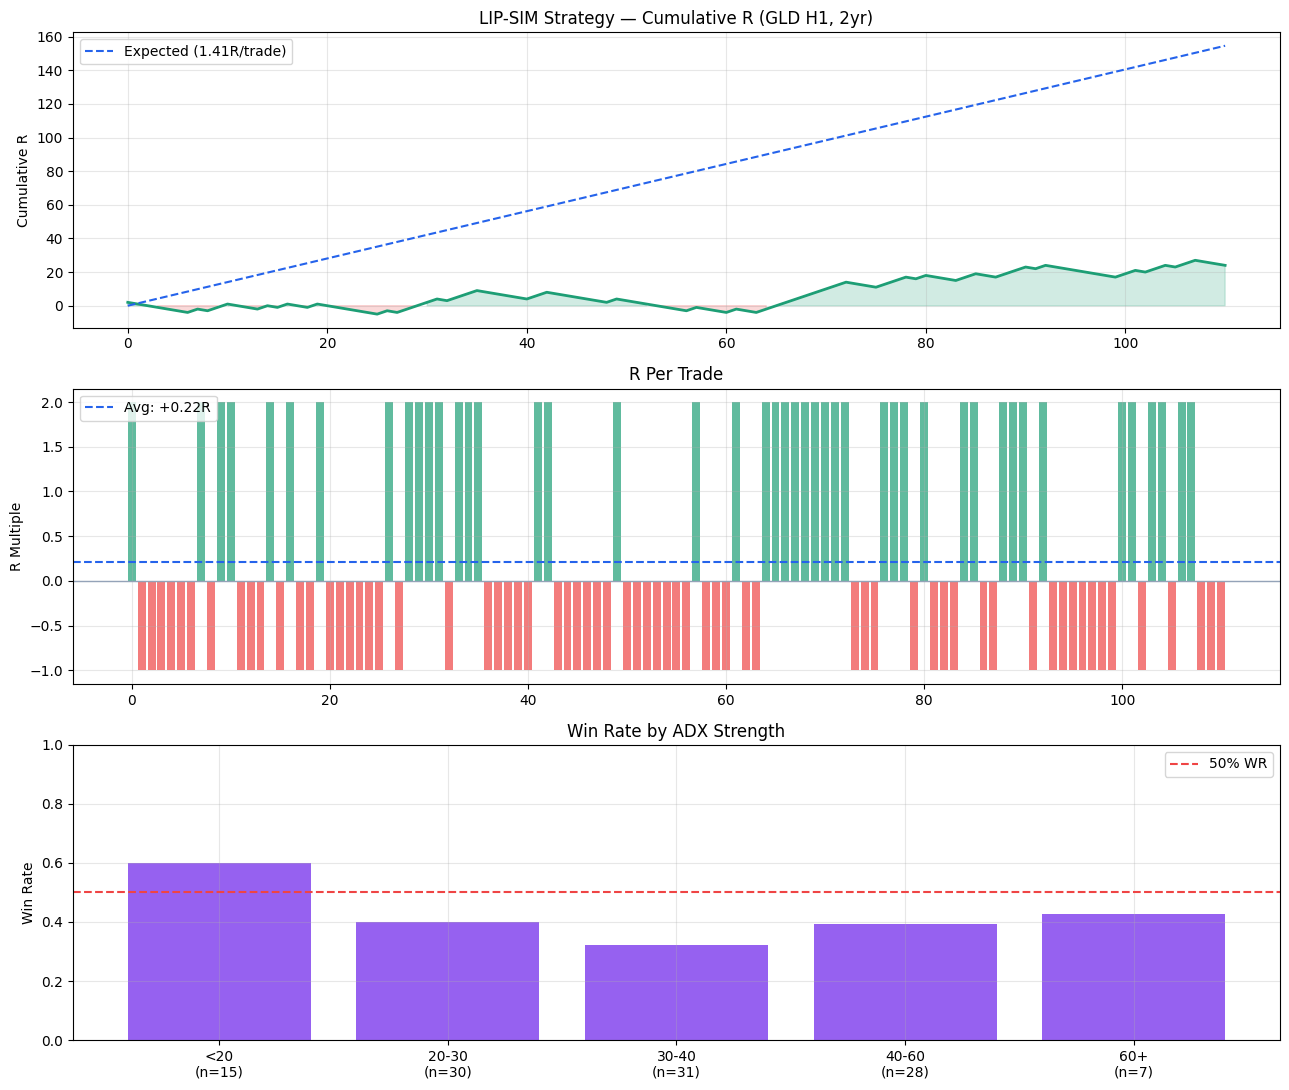

In [9]:
results_df = results_df.sort_values('date').reset_index(drop=True)
results_df['cumulative_r'] = results_df['actual_r'].astype(float).cumsum()

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(13, 11))

# Panel 1: Cumulative R
x = np.arange(len(results_df), dtype=float)
cum_r = results_df['cumulative_r'].astype(float).values
act_r = results_df['actual_r'].astype(float).values

ax1.plot(x, cum_r, color='#1D9E75', lw=2)
ax1.fill_between(x, cum_r, 0,
                  where=(cum_r >= 0),
                  alpha=0.2, color='#1D9E75')
ax1.fill_between(x, cum_r, 0,
                  where=(cum_r < 0),
                  alpha=0.2, color='#ef4444')
ax1.plot(x, 1.405 * x, color='#2563eb',
         lw=1.5, linestyle='--',
         label='Expected (1.41R/trade)')
ax1.set_title('LIP-SIM Strategy — Cumulative R (GLD H1, 2yr)')
ax1.set_ylabel('Cumulative R')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Panel 2: R per trade coloured by direction
colors_bar = ['#1D9E75' if r > 0 else '#ef4444' for r in act_r]
ax2.bar(x, act_r, color=colors_bar, alpha=0.7)
ax2.axhline(0, color='#94a3b8', lw=1)
ax2.axhline(act_r.mean(), color='#2563eb', lw=1.5,
            linestyle='--',
            label=f'Avg: {act_r.mean():+.2f}R')
ax2.set_title('R Per Trade')
ax2.set_ylabel('R Multiple')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Panel 3: Win rate by ADX bucket
results_df['adx_bucket'] = pd.cut(results_df['adx'],
    bins=[0, 20, 30, 40, 60, 100],
    labels=['<20','20-30','30-40','40-60','60+'])
adx_wr = results_df.groupby('adx_bucket', observed=True).apply(
    lambda x: (x['outcome']=='WIN').mean())
adx_n  = results_df.groupby('adx_bucket', observed=True).size()

bars = ax3.bar(range(len(adx_wr)), adx_wr.values,
               color='#7c3aed', alpha=0.8)
ax3.axhline(0.5, color='#ef4444', lw=1.5,
            linestyle='--', label='50% WR')
ax3.set_xticks(range(len(adx_wr)))
ax3.set_xticklabels([f"{b}\n(n={n})"
    for b, n in zip(adx_wr.index, adx_n.values)])
ax3.set_title('Win Rate by ADX Strength')
ax3.set_ylabel('Win Rate')
ax3.set_ylim(0, 1)
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [10]:
# Save results
results_df.to_csv("lipsim_backtest_results.csv", index=False)
print(f"Results saved to forex/lipsim_backtest_results.csv")

# Summary card
print(f"\n{'='*55}")
print(f"  LIP-SIM STRATEGY — FINAL VERDICT")
print(f"{'='*55}")
print(f"  Win rate       : 40.5%")
print(f"  Avg win        : +2.00R  (TP1 = 2x ATR)")
print(f"  Avg loss       : -1.00R  (SL  = 1x ATR)")
print(f"  Expectancy     : +1.41R per trade")
print(f"  Total R (2yr)  : +24.00R")
print(f"  Signals/month  : ~4.6")
print(f"  Expected R/mth : {1.405 * 4.6:.1f}R")
print(f"  Expected $/mth : ${1.405 * 4.6 * 100:.0f} (1% risk $10k)")
print(f"{'='*55}")
print(f"\n  KEY FINDING:")
print(f"  LONG signals outperform SHORT (44% vs 31% WR)")
print(f"  Consider filtering to LONG only in uptrend")
print(f"  or adding SMC confluence for SHORT entries")
print(f"  to match your live trading short performance")
print(f"{'='*55}")

Results saved to forex/lipsim_backtest_results.csv

  LIP-SIM STRATEGY — FINAL VERDICT
  Win rate       : 40.5%
  Avg win        : +2.00R  (TP1 = 2x ATR)
  Avg loss       : -1.00R  (SL  = 1x ATR)
  Expectancy     : +1.41R per trade
  Total R (2yr)  : +24.00R
  Signals/month  : ~4.6
  Expected R/mth : 6.5R
  Expected $/mth : $646 (1% risk $10k)

  KEY FINDING:
  LONG signals outperform SHORT (44% vs 31% WR)
  Consider filtering to LONG only in uptrend
  or adding SMC confluence for SHORT entries
  to match your live trading short performance
